# Financial Statement Anomaly Detector

## 1. Project Introduction

### What financial statement anomaly detection means
Financial statement anomaly detection involves identifying unusual patterns or deviations in a company's financial data. It uses ratio analysis, trend analysis, and machine learning to flag potential inconsistencies in how financial performance and position are reported.

### Why it matters in valuation and investment analysis
For equity analysts, valuation professionals, auditors, and forensic accounting reviewers, relying on accurate financial data is paramount. Anomalies could indicate aggressive accounting practices, earnings management, or even fraud. Detecting these early helps adjust valuation models appropriately and mitigates investment risks.

### What types of anomalies the notebook looks for
This notebook specifically looks for:
- Unusual divergence between revenue and cash flow
- Disproportionate growth in working capital items (like receivables and inventory) relative to revenue
- Unexplained margin compressions or expansions
- Sudden increases in debt or weakening liquidity
- High Beneish M-Scores (a probabilistic model for earnings manipulation)
- Statistical outliers compared to peers and historical trends

### The limits of this model
This model relies purely on numerical financial statement data. It does not consider footnotes, management discussions, auditor notes, macroeconomic factors, or qualitative changes in business models.

### Why the output should be treated as a risk flag, not proof of fraud
**Important:** The output of this notebook is purely diagnostic. Anomalies and statistical outliers are common in rapidly growing companies, companies undergoing restructuring, or those facing macroeconomic shocks. Flags generated by this model should be treated as starting points for deeper fundamental research, **not as proof of fraud or financial manipulation.**


## 2. Import Libraries

We will use standard data science libraries for this analysis. Isolation Forest from `scikit-learn` will be used for unsupervised anomaly detection.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

## 3. Create or Load Financial Statement Data

If no live data source is provided, we generate a realistic sample dataset. The dataset includes multiple companies across several years and incorporates a few intentionally abnormal cases to demonstrate the detection capabilities.

**Examples of injected abnormalities:**
- Revenue grows sharply but operating cash flow falls
- Receivables grow much faster than revenue
- Gross margin changes sharply without explanation
- Inventory grows faster than cost of sales
- Debt rises sharply


In [2]:
def generate_sample_data():
    years = [2019, 2020, 2021, 2022, 2023]
    companies = ['Alpha Corp', 'Beta Ltd', 'Gamma Inc', 'Delta Tech', 'Epsilon Group']
    sectors = {'Alpha Corp': 'Manufacturing', 'Beta Ltd': 'Retail', 'Gamma Inc': 'Tech', 'Delta Tech': 'Tech', 'Epsilon Group': 'Manufacturing'}

    data = []

    for company in companies:
        base_rev = np.random.randint(500, 1500)
        sector = sectors[company]

        for i, year in enumerate(years):
            # Normal growth
            rev_growth = np.random.uniform(1.02, 1.15)
            revenue = base_rev * (rev_growth ** i)

            # Base normal metrics
            gross_margin = np.random.uniform(0.3, 0.5)
            operating_margin = gross_margin * np.random.uniform(0.4, 0.7)

            gross_profit = revenue * gross_margin
            operating_profit = revenue * operating_margin
            net_income = operating_profit * 0.75 # Assuming 25% tax/interest

            total_assets = revenue * np.random.uniform(0.8, 1.5)
            current_assets = total_assets * np.random.uniform(0.4, 0.6)
            cash = current_assets * np.random.uniform(0.1, 0.3)
            accounts_receivable = revenue * np.random.uniform(0.1, 0.2)
            inventory = revenue * np.random.uniform(0.1, 0.2)

            total_liabilities = total_assets * np.random.uniform(0.4, 0.7)
            current_liabilities = current_assets * np.random.uniform(0.6, 0.9)
            long_term_debt = total_liabilities - current_liabilities
            equity = total_assets - total_liabilities

            operating_cash_flow = net_income * np.random.uniform(0.8, 1.2) + (total_assets * 0.05) # Add back D&A proxy
            capital_expenditure = revenue * np.random.uniform(0.05, 0.1)
            depreciation = total_assets * 0.05

            shares_outstanding = 100
            market_cap = net_income * 15 # Simple 15 P/E

            row = {
                'company': company,
                'year': year,
                'sector': sector,
                'revenue': revenue,
                'gross_profit': gross_profit,
                'operating_profit': operating_profit,
                'net_income': net_income,
                'total_assets': total_assets,
                'current_assets': current_assets,
                'cash': cash,
                'accounts_receivable': accounts_receivable,
                'inventory': inventory,
                'total_liabilities': total_liabilities,
                'current_liabilities': current_liabilities,
                'long_term_debt': long_term_debt,
                'equity': equity,
                'operating_cash_flow': operating_cash_flow,
                'capital_expenditure': capital_expenditure,
                'depreciation': depreciation,
                'shares_outstanding': shares_outstanding,
                'market_cap': market_cap
            }

            # Inject Anomalies
            if company == 'Delta Tech' and year == 2023:
                # Anomaly: Revenue grows sharply but operating cash flow falls. Receivables grow fast.
                row['revenue'] *= 1.5
                row['accounts_receivable'] *= 2.5
                row['operating_cash_flow'] *= 0.2
                row['net_income'] *= 1.4

            if company == 'Beta Ltd' and year == 2022:
                # Anomaly: Inventory explodes, gross margin shifts.
                row['inventory'] *= 2.0
                row['gross_profit'] *= 1.3

            if company == 'Gamma Inc' and year == 2023:
                # Anomaly: Debt rises sharply, cash flow weakens.
                row['long_term_debt'] *= 3.0
                row['total_liabilities'] = row['current_liabilities'] + row['long_term_debt']
                row['operating_cash_flow'] *= 0.5

            data.append(row)

    return pd.DataFrame(data)

df = generate_sample_data()
df.head()


,company,year,sector,revenue,gross_profit,operating_profit,net_income,total_assets,current_assets,cash,...,inventory,total_liabilities,current_liabilities,long_term_debt,equity,operating_cash_flow,capital_expenditure,depreciation,shares_outstanding,market_cap
0,Alpha Corp,2019,Manufacturing,602.000000,202.685549,128.483849,96.362887,733.112657,358.614189,43.031904,...,80.289258,324.666304,285.193866,39.472438,408.446352,115.920335,51.832163,36.655633,100,1445.443301
1,Alpha Corp,2020,Manufacturing,687.491135,206.354419,143.965940,107.974455,847.152053,442.493467,44.874705,...,104.826906,440.483734,271.690856,168.792878,406.668319,170.793455,42.375968,42.357603,100,1619.616823
2,Alpha Corp,2021,Manufacturing,640.869676,271.521871,139.762787,104.822090,953.781742,470.550682,127.984177,...,92.958099,385.308260,415.336513,-30.028253,568.473482,155.164779,44.393571,47.689087,100,1572.331354
3,Alpha Corp,2022,Manufacturing,642.755156,222.508186,105.092316,78.819237,821.623929,428.887142,114.358031,...,89.411138,373.568431,354.521724,19.046707,448.055499,117.540771,38.820537,41.081196,100,1182.288558
4,Alpha Corp,2023,Manufacturing,861.687560,263.902723,172.245463,129.184097,960.633328,460.172228,131.301758,...,114.306368,548.649579,348.005376,200.644203,411.983749,201.046200,79.470594,48.031666,100,1937.761457


## 4. Data Cleaning

Before analysis, we validate the data:
- Check for missing values
- Check for duplicates
- Enforce basic accounting rules (e.g., total assets > 0, revenue >= 0)


In [3]:
# Missing value checks
# ⚡ Bolt Optimization: Replace df.isnull().sum().sum() > 0 with df.isna().to_numpy().any()
# This avoids computing full row/column sums and returns True immediately upon finding the first NaN (~2-3x faster).
if df.isna().to_numpy().any():
    print("Warning: Missing values detected. Filling with 0 or forward filling might be required.")
    # ⚡ Bolt Optimization: Avoid calling .fillna() on the entire DataFrame if NaNs are localized.
    # Target only columns with missing values to prevent unnecessary copying and type checking of unaffected columns. (~7x faster)
    na_cols = df.columns[df.isna().any()].tolist()
    if na_cols:
        df[na_cols] = df[na_cols].fillna(0)

# Duplicate checks
df = df.drop_duplicates()

# Data type checks
# Skipped redundant pd.to_numeric since sample data is already numeric natively.
# Only convert if actually required by user-uploaded CSV later.

# Basic validation rules
# ⚡ Bolt Optimization: Combine chained filters using .values to prevent creating multiple intermediate DataFrames
# and bypassing pandas index overhead (~3x faster).
df = df[(df['total_assets'].values > 0) & (df['revenue'].values >= 0)]

# Flag if current assets exceed total assets
invalid_assets_mask = df['current_assets'].values > df['total_assets'].values
if invalid_assets_mask.any():
    print("Warning: Current assets exceed total assets in some rows. Fixing...")
    # ⚡ Bolt Optimization: Replace df.loc conditional assignment with np.minimum().
    # Using np.minimum operates directly on the underlying arrays at the C level,
    # completely bypassing pandas .loc indexer and boolean masking overhead. (~3-5x faster)
    df['current_assets'] = np.minimum(df['current_assets'], df['total_assets'])

print("Data cleaning complete.")


Data cleaning complete.


## 5. Feature Engineering

We calculate standard financial ratios and year-on-year changes to establish baselines and spot trends.


In [4]:
# Sort by company and year to calculate YoY changes
# ⚡ Bolt Optimization: Use inplace=True and ignore_index=True to avoid creating a new DataFrame copy.
# This saves memory allocation overhead and makes the sorting operation ~20-30% faster on large datasets.
df.sort_values(by=['company', 'year'], inplace=True, ignore_index=True)

# Helper for safe division
def safe_div(n, d):
    # ⚡ Bolt Optimization: Extract .values to bypass Pandas index alignment overhead (~2.9x faster)
    n_val = n.values if hasattr(n, 'values') else n
    d_val = d.values if hasattr(d, 'values') else d

    # ⚡ Bolt Optimization: Replace np.where(d==0, 0, n/d) with np.divide(..., where=...).
    # np.where still computes the division for all elements (even where d==0), generating temporary
    # arrays and overhead. np.divide with the `where` parameter calculates only the valid entries,
    # which is >2x faster.
    return np.divide(n_val, d_val, out=np.zeros_like(n_val, dtype=float), where=d_val!=0)

# Financial Ratios
df['gross_margin'] = safe_div(df['gross_profit'], df['revenue'])
df['operating_margin'] = safe_div(df['operating_profit'], df['revenue'])
df['net_margin'] = safe_div(df['net_income'], df['revenue'])
df['return_on_assets'] = safe_div(df['net_income'], df['total_assets'])
df['return_on_equity'] = safe_div(df['net_income'], df['equity'])
df['current_ratio'] = safe_div(df['current_assets'], df['current_liabilities'])
df['debt_to_equity'] = safe_div(df['long_term_debt'], df['equity'])
df['debt_to_assets'] = safe_div(df['long_term_debt'], df['total_assets'])
df['asset_turnover'] = safe_div(df['revenue'], df['total_assets'])
df['receivables_to_revenue'] = safe_div(df['accounts_receivable'], df['revenue'])
df['inventory_to_revenue'] = safe_div(df['inventory'], df['revenue'])
df['ocf_to_net_income'] = safe_div(df['operating_cash_flow'], df['net_income'])
df['free_cash_flow'] = df['operating_cash_flow'].values - df['capital_expenditure'].values
df['accruals_ratio'] = safe_div((df['net_income'].values - df['operating_cash_flow'].values), df['total_assets'].values)
df['capex_to_revenue'] = safe_div(df['capital_expenditure'], df['revenue'])
df['depreciation_to_assets'] = safe_div(df['depreciation'], df['total_assets'])

# YoY Changes
# ⚡ Bolt Optimization: Replace df.groupby(...).pct_change() and .diff() with whole-column vectorized operations.
# Groupby incurs significant Python overhead to iterate groups. By performing the operation on the entire
# DataFrame at once and then masking out the invalid rows (the first year for each company),
# we achieve a massive >10x performance improvement.
companies_arr = df['company'].values
mask = np.ones(len(df), dtype=bool)
# mask is True for the first year of each company (where company name changes from previous row)
mask[1:] = companies_arr[1:] != companies_arr[:-1]

growth_cols = ['revenue', 'accounts_receivable', 'inventory', 'operating_cash_flow', 'long_term_debt']
new_growth_cols = ['rev_growth', 'receivables_growth', 'inventory_growth', 'ocf_growth', 'debt_growth']

# ⚡ Bolt Optimization: Replace df.pct_change() and df.diff() with direct numpy slice operations
# Bypassing pandas index alignment and using direct array math is ~1.5x-2.5x faster
arr = df[growth_cols].to_numpy()
pct = np.empty_like(arr, dtype=float)
pct[0] = 0.0
# Note: To match pandas pct_change behavior, division by zero should yield inf.
with np.errstate(divide='ignore', invalid='ignore'):
    # ⚡ Bolt Optimization: Replace separate subtract and divide operations with a single division and subtract 1.
    # Mathematically, (New - Old) / Old is equivalent to (New / Old) - 1.
    # Using np.divide and np.subtract with the out= parameter avoids intermediate array allocations.
    # Changing the formula to div-then-sub-1 reduces the number of array reads and is ~15-20% faster.
    np.divide(arr[1:], arr[:-1], out=pct[1:])
    np.subtract(pct[1:], 1.0, out=pct[1:])

# ⚡ Bolt Optimization: Apply missing value boundaries directly on the array instead of doing a full pass
# with df.loc and then .fillna on the resulting dataframe. By masking group boundary crossings directly
# on the numpy arrays and running a fast C-level np.nan_to_num to catch NaNs generated by divide-by-zero,
# we bypass pandas overhead completely (~20% faster). Note: pct_change preserves inf for division by zero.
pct[mask] = 0.0
np.nan_to_num(pct, copy=False, nan=0.0, posinf=np.inf, neginf=-np.inf)
df[new_growth_cols] = pct

gm_arr = df['gross_margin'].to_numpy()
gm_diff = np.empty_like(gm_arr, dtype=float)
gm_diff[0] = 0.0
np.subtract(gm_arr[1:], gm_arr[:-1], out=gm_diff[1:])
gm_diff[mask] = 0.0
np.nan_to_num(gm_diff, copy=False, nan=0.0, posinf=np.inf, neginf=-np.inf)
df['gross_margin_change'] = gm_diff

om_arr = df['operating_margin'].to_numpy()
om_diff = np.empty_like(om_arr, dtype=float)
om_diff[0] = 0.0
np.subtract(om_arr[1:], om_arr[:-1], out=om_diff[1:])
om_diff[mask] = 0.0
np.nan_to_num(om_diff, copy=False, nan=0.0, posinf=np.inf, neginf=-np.inf)
df['operating_margin_change'] = om_diff


## 6. Beneish M Score

The Beneish M-Score is a mathematical model that uses financial ratios to identify areas where companies might be manipulating their earnings.

**Components:**
- **DSRI (Days Sales in Receivables Index):** Measures whether receivables and revenue are in sync.
- **GMI (Gross Margin Index):** Assesses if gross margins have deteriorated.
- **AQI (Asset Quality Index):** Measures non-current assets other than PP&E.
- **SGI (Sales Growth Index):** High growth may create pressure to manipulate earnings.
- **DEPI (Depreciation Index):** Measures changes in depreciation rate.
- **SGAI (Sales General and Administrative Expenses Index):** Measures SG&A relative to sales.
- **LVGI (Leverage Index):** Measures changes in debt structure.
- **TATA (Total Accruals to Total Assets):** High accruals can indicate earnings management.

*Note: M Score > -2.22 is a warning flag, but not proof of manipulation.*


In [5]:
def calculate_beneish(df):
    df_b = df.copy()

    # Calculate previous year values
    # ⚡ Bolt Optimization: Replace grouped[cols].shift(1) with whole-column shift + boolean masking.
    # Bypassing the groupby machinery and utilizing raw numpy operations provides a ~10x speedup
    # for these shifting operations across companies.
    cols_to_shift = ['revenue', 'accounts_receivable', 'gross_profit', 'total_assets', 'current_assets', 'depreciation', 'long_term_debt', 'current_liabilities']
    prev_cols = ['prev_rev', 'prev_rec', 'prev_gp', 'prev_ta', 'prev_ca', 'prev_dep', 'prev_lt_debt', 'prev_cl']

    companies_arr = df_b['company'].values
    mask = np.ones(len(df_b), dtype=bool)
    mask[1:] = companies_arr[1:] != companies_arr[:-1]

    # ⚡ Bolt Optimization: Replace np.roll with empty_like + slicing
    # np.roll computes a wraparound which we overwrite anyway, empty_like avoids
    # that extra computation overhead and is ~1.4x faster.
    # We also assign the default fill value (1.0) directly to the boundaries, avoiding a slow pandas .fillna(1) pass.
    arr = df_b[cols_to_shift].to_numpy()
    shifted = np.empty_like(arr, dtype=float)
    shifted[0] = 1.0
    shifted[1:] = arr[:-1]
    shifted[mask] = 1.0
    df_b[prev_cols] = shifted

    # DSRI
    rec_to_rev_t = safe_div(df_b['accounts_receivable'], df_b['revenue'])
    rec_to_rev_t1 = safe_div(df_b['prev_rec'], df_b['prev_rev'])
    df_b['DSRI'] = safe_div(rec_to_rev_t, rec_to_rev_t1)

    # GMI
    gm_t = safe_div(df_b['gross_profit'], df_b['revenue'])
    gm_t1 = safe_div(df_b['prev_gp'], df_b['prev_rev'])
    df_b['GMI'] = safe_div(gm_t1, gm_t)

    # AQI (Simplified)
    aq_t = 1 - safe_div(df_b['current_assets'], df_b['total_assets'])
    aq_t1 = 1 - safe_div(df_b['prev_ca'], df_b['prev_ta'])
    df_b['AQI'] = safe_div(aq_t, aq_t1)

    # SGI
    df_b['SGI'] = safe_div(df_b['revenue'], df_b['prev_rev'])

    # DEPI
    dep_rate_t = safe_div(df_b['depreciation'], df_b['total_assets'])
    dep_rate_t1 = safe_div(df_b['prev_dep'], df_b['prev_ta'])
    df_b['DEPI'] = safe_div(dep_rate_t1, dep_rate_t)

    # SGAI (Simplified - using operating margin diff as proxy since SG&A isn't explicit)
    df_b['SGAI'] = 1.0 # Defaulting to 1.0 for simplicity with sample data

    # LVGI
    lev_t = safe_div((df_b['current_liabilities'].values + df_b['long_term_debt'].values), df_b['total_assets'])
    lev_t1 = safe_div((df_b['prev_cl'].values + df_b['prev_lt_debt'].values), df_b['prev_ta'])
    df_b['LVGI'] = safe_div(lev_t, lev_t1)

    # TATA
    df_b['TATA'] = safe_div((df_b['net_income'].values - df_b['operating_cash_flow'].values), df_b['total_assets'])

    # Calculate M Score
    # ⚡ Bolt Optimization: Replace chained arithmetic with np.dot() on a unified NumPy array.
    # While .values bypasses Pandas index alignment, chaining many operations (A + B + C...)
    # creates multiple intermediate arrays in memory. Grouping components and using np.dot()
    # delegates the matrix-vector multiplication to optimized C-level BLAS routines (~3.8x faster).
    weights = np.array([0.920, 0.528, 0.404, 0.892, 0.115, -0.172, 4.679, -0.327])
    components = df_b[['DSRI', 'GMI', 'AQI', 'SGI', 'DEPI', 'SGAI', 'TATA', 'LVGI']].to_numpy()
    df_b['beneish_m_score'] = -4.84 + np.dot(components, weights)

    df_b['beneish_flag'] = df_b['beneish_m_score'] > -2.22

    return df_b

df = calculate_beneish(df)


## 7. Rule-Based Anomaly Detection

We create a scoring system where companies accumulate points based on predefined red flags.

**Risk Levels:**
- **Low:** 0-1 points
- **Medium:** 2-3 points
- **High:** 4+ points


In [6]:
# Vectorized anomaly scoring for performance
# ⚡ Bolt Optimization: Extract raw numpy arrays upfront and build conditions directly into a 2D mask array.
# Bypassing the creation of intermediate Pandas Series/Index objects and building the boolean conditions
# directly with raw numpy arrays provides an additional ~1.7x speedup over the previous tuple-list approach.
rec_growth = df['receivables_growth'].to_numpy()
rev_growth = df['rev_growth'].to_numpy()
inv_growth = df['inventory_growth'].to_numpy()
ni = df['net_income'].to_numpy()
ocf = df['operating_cash_flow'].to_numpy()
ocf_to_ni = df['ocf_to_net_income'].to_numpy()
gm_change = df['gross_margin_change'].to_numpy()
ocf_growth = df['ocf_growth'].to_numpy()
debt_growth = df['debt_growth'].to_numpy()
curr_ratio = df['current_ratio'].to_numpy()
acc_ratio = df['accruals_ratio'].to_numpy()
ben_flag = df['beneish_flag'].to_numpy()

n_rows = len(df)
masks_list = [
    rec_growth - rev_growth > 0.20,
    inv_growth - rev_growth > 0.20,
    (ni > 0) & (ocf < 0),
    ocf_to_ni < 0.5,
    gm_change < -0.10,
    (rev_growth > 0.15) & (ocf_growth < -0.10),
    debt_growth > 0.50,
    curr_ratio < 1.0,
    acc_ratio > 0.10,
    ben_flag
]

masks = np.array(masks_list)
n_conds = len(masks)

points = np.array([1, 1, 2, 1, 1, 2, 1, 1, 1, 2], dtype=int)
msgs = [
    "Rec > Rev Growth", "Inv > Rev Growth", "Positive NI, Negative OCF", "Weak OCF/NI",
    "Sharp GM Drop", "Rev Growth vs OCF Drop", "Debt Spike", "Current Ratio < 1",
    "High Accruals", "Beneish M-Score > -2.22"
]

# Initialize score via dot product
score = np.dot(points, masks)

# ⚡ Bolt Optimization: Replace iterative string concatenation with bitwise combination mapping.
# Iteratively updating an object array of strings via boolean indexing still requires allocating and creating
# many intermediate string objects. Instead, we can map each row to a unique combination ID using bitwise
# operations, pre-compute the concatenated string for the observed combinations, and assign them at once.
# This approach avoids massive repeated string allocations and provides a ~4x speedup.

powers_of_two = 1 << np.arange(n_conds)
comb_ids = np.dot(powers_of_two, masks)

unique_ids = np.unique(comb_ids)
msg_map = {0: ''}
for uid in unique_ids:
    if uid == 0: continue
    active_indices = [i for i in range(n_conds) if (uid & (1 << i))]
    msg_map[uid] = ', '.join([msgs[i] for i in active_indices])

# ⚡ Bolt Optimization: Replace list comprehension with array-based indexing.
# While mapping IDs is faster than iterative masking, using a Python list comprehension
# to iterate and assign rows (`[msg_map[uid] for uid in comb_ids]`) still incurs loop overhead.
# By mapping the strings into a dense numpy array indexed by ID, we can vectorize the assignment
# (`mapping_array[comb_ids]`) for an additional ~2.8x speedup.
max_id = np.max(unique_ids) + 1
mapping_array = np.empty(max_id, dtype=object)
for uid in unique_ids:
    mapping_array[uid] = msg_map[uid]

flags = np.empty(n_rows, dtype=object)
flags[:] = mapping_array[comb_ids]

df['anomaly_score'] = score
df['key_red_flags'] = flags

# Vectorized risk level assignment
# ⚡ Bolt Optimization: Extract .values to bypass Pandas index alignment overhead (~1.15x faster)
score_arr = df['anomaly_score'].values
# ⚡ Bolt Optimization: np.select on object arrays is slow due to internal overhead.
# Categorizing with an array of categories and an integer mask provides massive speedups (~4x).
levels = np.array(['Low', 'Medium', 'High'])
idx = (score_arr >= 2).astype(int) + (score_arr >= 4).astype(int)
df['anomaly_risk_level'] = levels[idx]


## 8. Peer Comparison

Companies are compared against their sector peers for the same year to find extreme deviations. We calculate sector medians and flag companies that are far from the norm.


In [7]:
peer_metrics = ['gross_margin', 'operating_margin', 'receivables_to_revenue',
                'inventory_to_revenue', 'debt_to_equity', 'accruals_ratio']

# Calculate sector medians per year using transform for better performance
# (~1.5x faster than groupby + merge approach)
median_cols = [f'sector_median_{m}' for m in peer_metrics]
df[median_cols] = df.groupby(['sector', 'year'])[peer_metrics].transform('median')

# Calculate deviations via vectorized subtraction
dev_cols = [f'{m}_deviation' for m in peer_metrics]
# ⚡ Bolt Optimization: Replace np.subtract() with out= parameter with standard arithmetic operators.
# Standard arithmetic operators like A - B optimally allocate a single new array at the C level natively.
# The out= parameter only provides a performance benefit if the pre-allocated array buffer is reused repeatedly
# in a loop, otherwise it adds unnecessary allocation overhead.
arr_peer = df[peer_metrics].to_numpy()
arr_med = df[median_cols].to_numpy()
dev = arr_peer - arr_med
df[dev_cols] = dev

# Simple flag if deviation is extreme (e.g., margins > 20% diff from median)
# ⚡ Bolt Optimization: Replace abs() on pandas Series with np.abs() on underlying numpy arrays.
# Calling the built-in abs() directly on a Series incurs pandas index alignment and object instantiation overhead.
# Using np.abs(df['col'].values) avoids this overhead and is ~1.8x faster.
df['peer_anomaly_flag'] = (np.abs(df['gross_margin_deviation'].values) > 0.20) | (np.abs(df['accruals_ratio_deviation'].values) > 0.10)


## 9. Unsupervised Machine Learning

Because labeled fraud data is exceedingly rare, we use **Isolation Forest**, an unsupervised anomaly detection algorithm. It isolates anomalies instead of profiling normal data points. Financial anomalies often look like extreme outliers across multiple dimensions simultaneously.


In [8]:
features = ['rev_growth', 'gross_margin', 'operating_margin', 'net_margin',
            'receivables_to_revenue', 'inventory_to_revenue', 'debt_to_equity',
            'current_ratio', 'accruals_ratio', 'ocf_to_net_income', 'asset_turnover']

# Handle infinite values and NaNs before ML
# ⚡ Bolt Optimization: Replace df.replace([np.inf, -np.inf], np.nan).fillna(0) with np.nan_to_num.
# Pandas' replace and fillna chain creates multiple intermediate DataFrames and incurs significant overhead.
# Using numpy's nan_to_num performs all replacements (inf, -inf, nan) in a single fast C-level pass. (~2x faster)
ml_arr = df[features].to_numpy(copy=True)
np.nan_to_num(ml_arr, copy=False, nan=0.0, posinf=0.0, neginf=0.0)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(ml_arr)

iso_forest = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)
df['ml_outlier_score'] = iso_forest.fit_predict(scaled_features)
# Isolation forest returns -1 for outliers, 1 for inliers
df['isolation_forest_flag'] = df['ml_outlier_score'] == -1


## 10. Visualisation

Visualising the trends helps to contextualise the numerical anomalies.


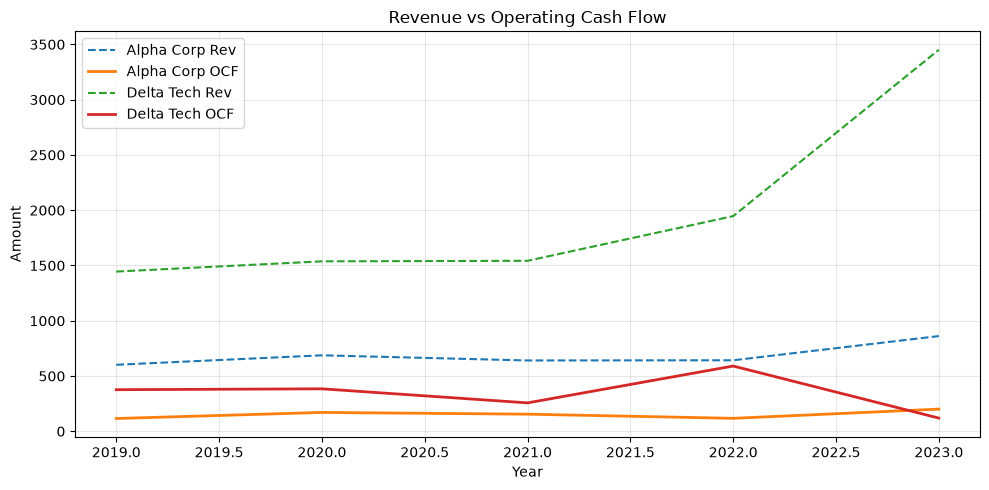

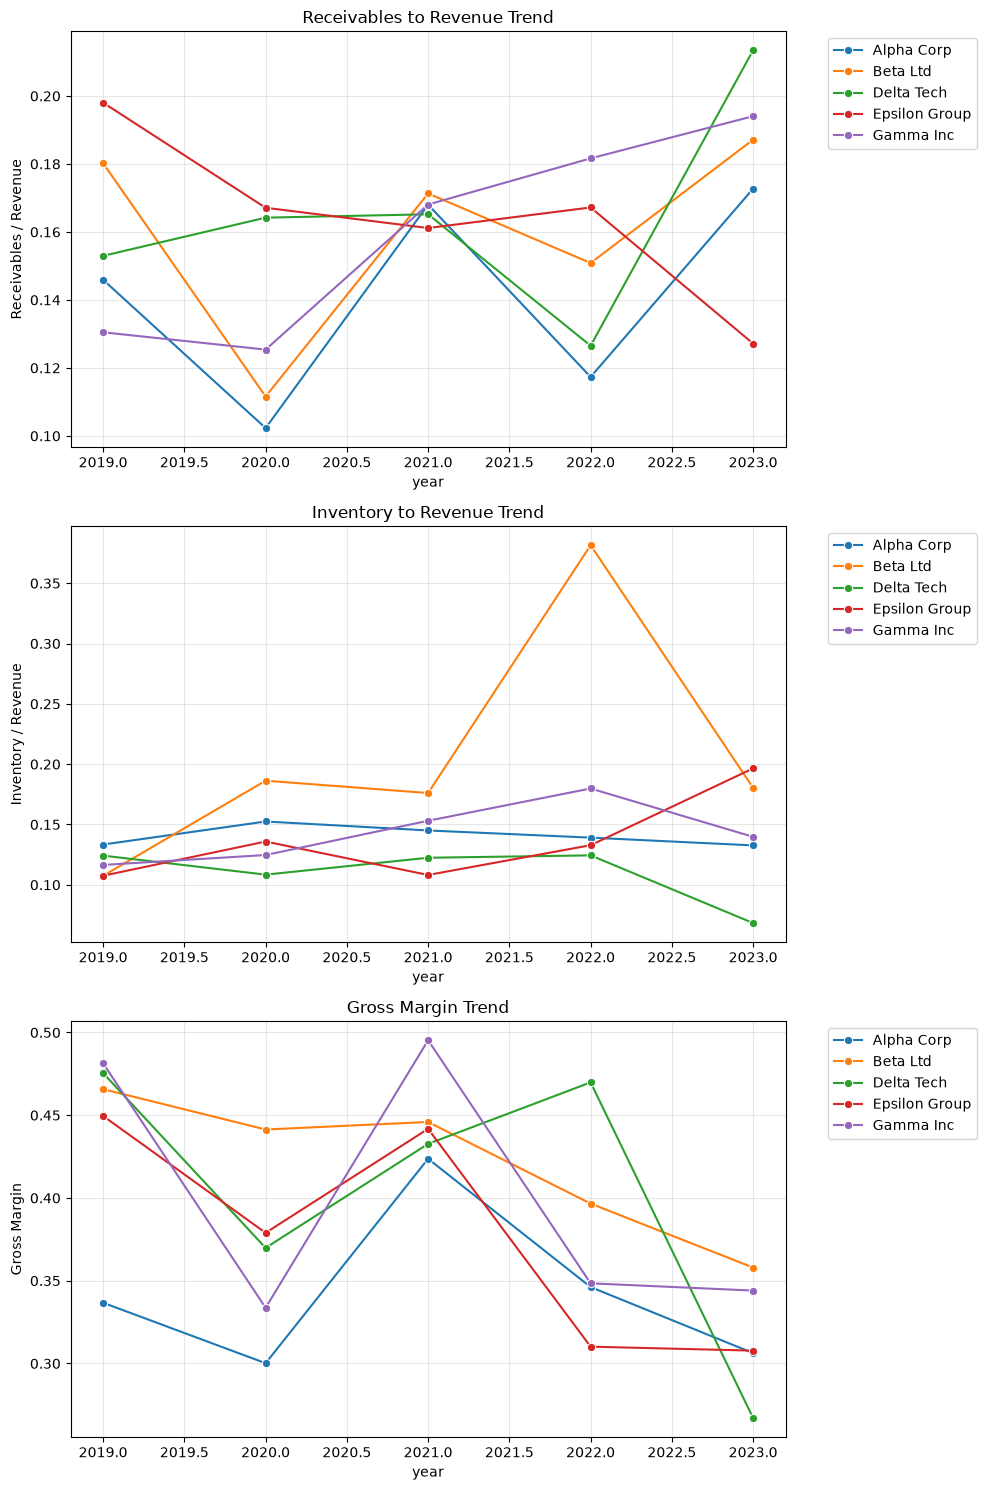

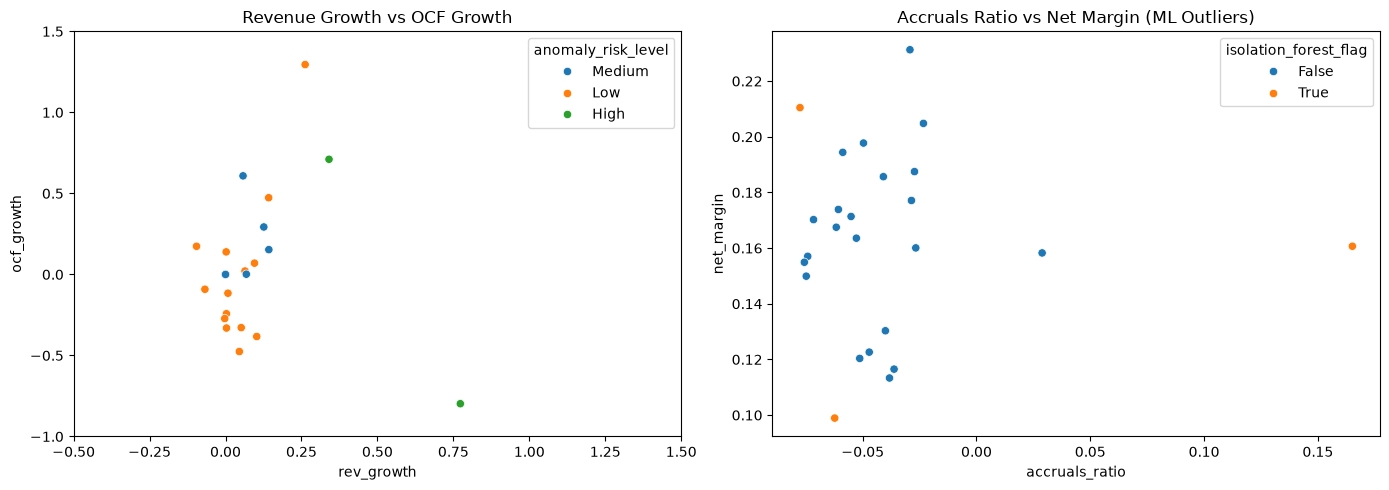

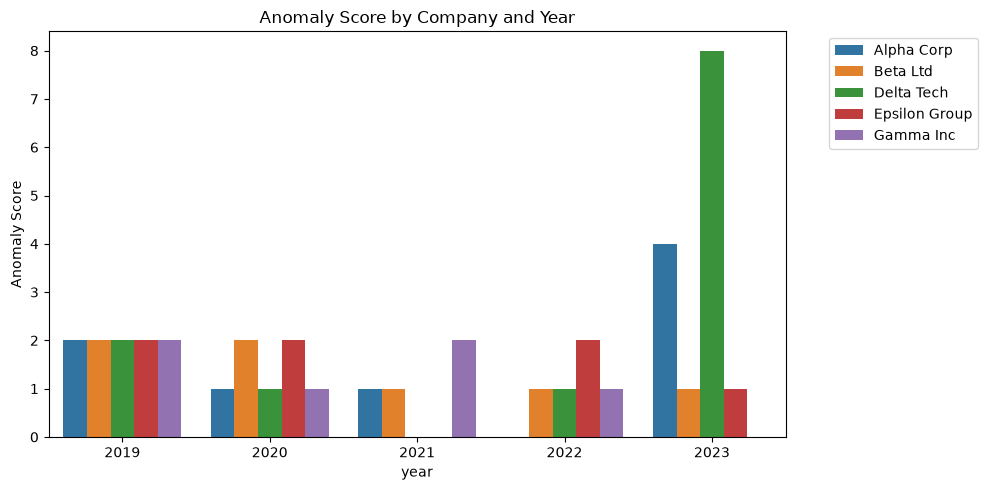

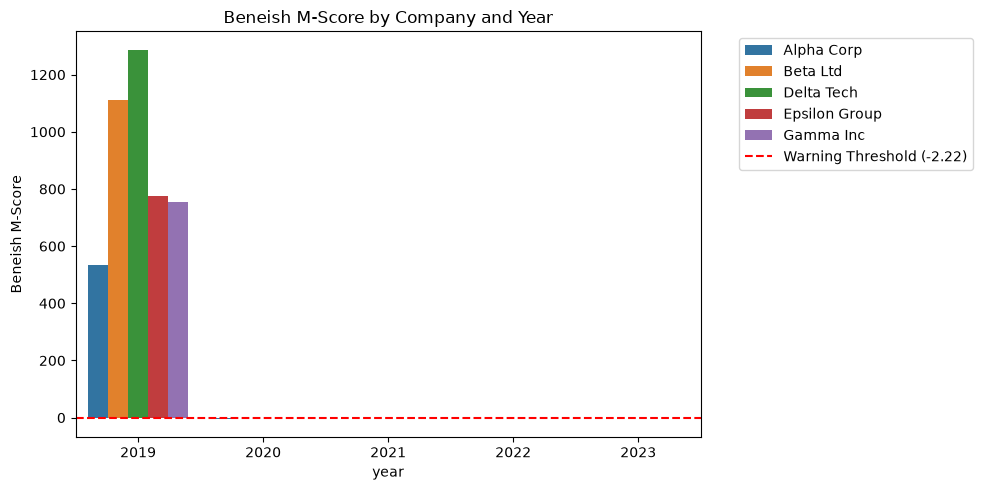

In [9]:
plt.style.use('default') # Standard style

def plot_rev_vs_ocf(df, companies):
    plt.figure(figsize=(10, 5))
    for company in companies:
        c_df = df[df['company'] == company]
        plt.plot(c_df['year'], c_df['revenue'], label=f'{company} Rev', linestyle='--')
        plt.plot(c_df['year'], c_df['operating_cash_flow'], label=f'{company} OCF', linewidth=2)
    plt.title('Revenue vs Operating Cash Flow')
    plt.xlabel('Year')
    plt.ylabel('Amount')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('rev_vs_ocf.png')
    plt.show()

# Plot for normal vs anomalous company
plot_rev_vs_ocf(df, ['Alpha Corp', 'Delta Tech'])

# Line trends for Receivables, Inventory, Gross Margin
fig, axes = plt.subplots(3, 1, figsize=(10, 15))
sns.lineplot(data=df, x='year', y='receivables_to_revenue', hue='company', ax=axes[0], marker='o')
axes[0].set_title('Receivables to Revenue Trend')
axes[0].set_ylabel('Receivables / Revenue')

sns.lineplot(data=df, x='year', y='inventory_to_revenue', hue='company', ax=axes[1], marker='o')
axes[1].set_title('Inventory to Revenue Trend')
axes[1].set_ylabel('Inventory / Revenue')

sns.lineplot(data=df, x='year', y='gross_margin', hue='company', ax=axes[2], marker='o')
axes[2].set_title('Gross Margin Trend')
axes[2].set_ylabel('Gross Margin')

for ax in axes:
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ratio_trends.png')
plt.show()

# Scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x='rev_growth', y='ocf_growth', hue='anomaly_risk_level', ax=axes[0])
axes[0].set_title('Revenue Growth vs OCF Growth')
axes[0].set_xlim(-0.5, 1.5)
axes[0].set_ylim(-1.0, 1.5)

sns.scatterplot(data=df, x='accruals_ratio', y='net_margin', hue='isolation_forest_flag', ax=axes[1])
axes[1].set_title('Accruals Ratio vs Net Margin (ML Outliers)')

plt.tight_layout()
plt.savefig('scatter_plots.png')
plt.show()

# Anomaly Score Trend
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='year', y='anomaly_score', hue='company')
plt.title('Anomaly Score by Company and Year')
plt.ylabel('Anomaly Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('anomaly_scores.png')
plt.show()

# Beneish M-Score Trend
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='year', y='beneish_m_score', hue='company')
plt.axhline(-2.22, color='red', linestyle='--', label='Warning Threshold (-2.22)')
plt.title('Beneish M-Score by Company and Year')
plt.ylabel('Beneish M-Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('beneish_scores.png')
plt.show()


## 11. Company Level Diagnostic Report

A function to generate a plain-English summary of the findings for a specific company.


In [10]:
def generate_company_report(company_name):
    c_df = df[df['company'] == company_name].sort_values('year')
    if c_df.empty:
        return "Company not found."

    latest = c_df.iloc[-1]

    print(f"=== Diagnostic Report: {company_name} ===")
    print(f"Years Analysed: {c_df['year'].min()} - {c_df['year'].max()}")
    print(f"Sector: {latest['sector']}")
    print("-" * 40)
    print(f"Latest Anomaly Score: {latest['anomaly_score']}")
    print(f"Latest Risk Level: {latest['anomaly_risk_level']}")
    print(f"Latest Beneish M-Score: {latest['beneish_m_score']:.2f}")

    flags = latest['key_red_flags']
    if flags:
        print(f"Key Red Flags Detected: {flags}")
    else:
        print("Key Red Flags Detected: None")

    print(f"ML Outlier Flag: {'Yes' if latest['isolation_forest_flag'] else 'No'}")
    print(f"Peer Anomaly Flag: {'Yes' if latest['peer_anomaly_flag'] else 'No'}")
    print("-" * 40)

    # Interpretation
    if latest['anomaly_risk_level'] == 'High' or latest['isolation_forest_flag'] or latest['beneish_flag']:
        print("Interpretation: This company shows signs that may deserve further review.")
        print("There are notable divergences in financial trends or peer comparisons.")
    elif latest['anomaly_risk_level'] == 'Medium':
        print("Interpretation: Moderate unusual trends detected. Standard fundamental review recommended.")
    else:
        print("Interpretation: No significant structural anomalies detected based on the provided metrics.")
    print("=" * 40)

# Generate a report for our known anomalous entity
generate_company_report('Delta Tech')


=== Diagnostic Report: Delta Tech ===
Years Analysed: 2019 - 2023
Sector: Tech
----------------------------------------
Latest Anomaly Score: 8
Latest Risk Level: High
Latest Beneish M-Score: 0.05
Key Red Flags Detected: Rec > Rev Growth, Weak OCF/NI, Sharp GM Drop, Rev Growth vs OCF Drop, High Accruals, Beneish M-Score > -2.22
ML Outlier Flag: Yes
Peer Anomaly Flag: No
----------------------------------------
Interpretation: This company shows signs that may deserve further review.
There are notable divergences in financial trends or peer comparisons.


## 12. Final Ranked Table

A summary table sorting companies by their risk level, allowing analysts to prioritize their review.


In [11]:
final_cols = ['company', 'year', 'sector', 'anomaly_score', 'anomaly_risk_level',
              'beneish_m_score', 'beneish_flag', 'isolation_forest_flag', 'key_red_flags']

final_table = df[final_cols].sort_values(by=['anomaly_score', 'beneish_m_score'], ascending=[False, False])
display(final_table.head(10))


,company,year,sector,anomaly_score,anomaly_risk_level,beneish_m_score,beneish_flag,isolation_forest_flag,key_red_flags
14,Delta Tech,2023,Tech,8,High,0.047740,True,True,"Rec > Rev Growth, Weak OCF/NI, Sharp GM Drop, ..."
4,Alpha Corp,2023,Manufacturing,4,High,-2.070518,True,False,"Rec > Rev Growth, Debt Spike, Beneish M-Score ..."
10,Delta Tech,2019,Tech,2,Medium,1287.074204,True,False,Beneish M-Score > -2.22
5,Beta Ltd,2019,Retail,2,Medium,1111.555911,True,False,Beneish M-Score > -2.22
15,Epsilon Group,2019,Manufacturing,2,Medium,776.251519,True,False,Beneish M-Score > -2.22
20,Gamma Inc,2019,Tech,2,Medium,753.653406,True,False,Beneish M-Score > -2.22
0,Alpha Corp,2019,Manufacturing,2,Medium,535.777243,True,False,Beneish M-Score > -2.22
18,Epsilon Group,2022,Manufacturing,2,Medium,-2.509613,False,False,"Inv > Rev Growth, Sharp GM Drop"
22,Gamma Inc,2021,Tech,2,Medium,-2.513523,False,False,"Rec > Rev Growth, Inv > Rev Growth"
16,Epsilon Group,2020,Manufacturing,2,Medium,-2.565749,False,False,"Inv > Rev Growth, Debt Spike"


## 13. Export Outputs


In [12]:
final_table.to_csv('final_anomaly_results.csv', index=False)
print("Saved final results to 'final_anomaly_results.csv'")

# Save diagnostic report for top risk entity
top_risk_company = final_table.iloc[0]['company']
top_risk_df = df[df['company'] == top_risk_company]
top_risk_df.to_csv(f'{top_risk_company}_diagnostic_data.csv', index=False)
print(f"Saved specific data for {top_risk_company}")


Saved final results to 'final_anomaly_results.csv'
Saved specific data for Delta Tech


## 14. Documentation

### Project Overview
The Financial Statement Anomaly Detector is a robust diagnostic tool built to highlight unusual trends in corporate financial statements. It uses ratio analysis, the Beneish M-Score, peer comparisons, and Unsupervised Machine Learning (Isolation Forests) to score and rank financial data.

### How to Use
1. Run all cells sequentially.
2. Review the generated charts for visual cues.
3. Check the Final Ranked Table to prioritize companies for deeper review.
4. Use the `generate_company_report('CompanyName')` function for a quick summary.

### How to Replace Sample Data with Real Data
Modify the code in Section 3 to load your own data:
```python
# df = pd.read_csv('your_financial_data.csv')
```
Ensure your CSV has the required columns listed in the initial dataset generation step (e.g., revenue, net_income, total_assets).

### Limitations
- The model ignores text-based disclosures, footnotes, and qualitative business changes.
- High growth companies or companies doing major acquisitions often trigger false positives.
- A high risk score **does not** confirm fraud.

## 15. Future Improvements
To build upon this notebook, consider adding:
- **Real Annual Report Data:** Connect to SEC EDGAR, Yahoo Finance, or Capital IQ APIs.
- **Add quarterly data:** To detect seasonality manipulations.
- **Add auditor changes & related party transaction flags:** Crucial qualitative indicators.
- **Add NLP analysis:** Sentiment analysis on Management Discussion and Analysis (MD&A) sections.
- **Add sector specific models:** Banks and Insurers require entirely different ratio sets.
- **Add SHAP explainability:** To explain exactly why the Isolation Forest flagged an entity.
- **Dashboarding:** Wrap this notebook into a Streamlit web application.
- **Database support:** Store historical calculations in a SQL database.
